<a href="https://colab.research.google.com/github/purusottamdash0-collab/Quality-Prediction-In-minning-Project/blob/main/Quality_Prediction_In_minning_Project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip install gdown xgboost scikit-learn pandas numpy matplotlib seaborn

In [ ]:
# Cell 2: Drive se data download karna
import gdown
import os

print("Dataset is downloded")

# link exact File ID
file_id = '1N80d8eTDAf1JMQXGQbHDAUaMGRyA8QG3'
url = f'https://drive.google.com/uc?id={file_id}'
output_file = 'mining_data.csv'

if not os.path.exists(output_file):
    gdown.download(url, output_file, quiet=False)
    print("Download complete!")
else:
    print("File already downloaded hai.")

Dataset is downloded
File already downloaded hai.


In [ ]:
# Cell 3: ZIP handling logic update
import pandas as pd
import numpy as np
import zipfile
import os

def extract_nested_zip(zip_path, extract_to='.'):
    with zipfile.ZipFile(zip_path, 'r') as z:
        for file_info in z.infolist():
            if not file_info.is_dir():
                z.extract(file_info, extract_to)
                # Agar extracted file khud ek zip hai, usse bhi extract karo
                if file_info.filename.endswith('.zip'):
                    new_path = os.path.join(extract_to, file_info.filename)
                    return extract_nested_zip(new_path, extract_to)
                # Agar CSV mil gayi
                if file_info.filename.endswith('.csv'):
                    return os.path.join(extract_to, file_info.filename)
    return None

if zipfile.is_zipfile('mining_data.csv'):
    print("Zip file processed...")
    csv_path = extract_nested_zip('mining_data.csv')
else:
    csv_path = 'mining_data.csv'

if csv_path and os.path.exists(csv_path):
    print(f"Loading data from: {csv_path}")
    # Using comma separator for this specific extracted CSV
    df = pd.read_csv(csv_path, encoding='latin1', sep=',')

    df.columns = [c.strip() for c in df.columns]
    date_col = df.columns[0]

    # Converting date column
    df[date_col] = pd.to_datetime(df[date_col], errors='coerce')
    df = df.dropna(subset=[date_col])
    df.set_index(date_col, inplace=True)

    # Convert numeric columns - standardizing potential comma decimals
    for col in df.columns:
        if df[col].dtype == 'object':
            df[col] = df[col].str.replace(',', '.').astype(float)
        else:
            df[col] = pd.to_numeric(df[col], errors='coerce')

    print("Data successfully load ")
    display(df.head(3))
else:
    print("Error: CSV file is not found")

Zip file processed...
Loading data from: ./MiningProcess_Flotation_Plant_Database.csv
Data successfully load 


,% Iron Feed,% Silica Feed,Starch Flow,Amina Flow,Ore Pulp Flow,Ore Pulp pH,Ore Pulp Density,Flotation Column 01 Air Flow,Flotation Column 02 Air Flow,Flotation Column 03 Air Flow,...,Flotation Column 07 Air Flow,Flotation Column 01 Level,Flotation Column 02 Level,Flotation Column 03 Level,Flotation Column 04 Level,Flotation Column 05 Level,Flotation Column 06 Level,Flotation Column 07 Level,% Iron Concentrate,% Silica Concentrate
date,,,,,,,,,,,,,,,,,,,,,
2017-03-10 01:00:00,55.2,16.98,3019.53,557.434,395.713,10.0664,1.74,249.214,253.235,250.576,...,250.884,457.396,432.962,424.954,443.558,502.255,446.370,523.344,66.91,1.31
2017-03-10 01:00:00,55.2,16.98,3024.41,563.965,397.383,10.0672,1.74,249.719,250.532,250.862,...,248.994,451.891,429.560,432.939,448.086,496.363,445.922,498.075,66.91,1.31
2017-03-10 01:00:00,55.2,16.98,3043.46,568.054,399.668,10.0680,1.74,249.741,247.874,250.313,...,248.071,451.240,468.927,434.610,449.688,484.411,447.826,458.567,66.91,1.31


In [ ]:
# Cell 4: 1-Minute interval par resampling
print(" 1-Minute interval par resampling")

# '1T' matlab 1 Minute. Hum har minute ka average (mean) nikal rahe hain
df_minute = df.resample('1T').mean()

# Forward fill (ffill) aur backward fill (bfill) use karke missing values handle karna
df_minute = df_minute.ffill().bfill()

print("Resampling done! Shape of new data:", df_minute.shape)

 1-Minute interval par resampling


/tmp/ipykernel_1154/1253322400.py:5: FutureWarning: 'T' is deprecated and will be removed in a future version, please use 'min' instead.
  df_minute = df.resample('1T').mean()


Resampling done! Shape of new data: (264841, 23)


In [ ]:
# Cell 5: Features aur Target ko separate karna
# Last column % of silica hai (Target) [cite: 15]
target_col = df_minute.columns[-1]

# Second last column % Iron hai, jisko hume exclude karna hai
iron_col = df_minute.columns[-2]

print(f"Target Column (Predict karna hai): {target_col}")
print(f"Dropping Column (Highly correlated): {iron_col}")

X = df_minute.drop(columns=[target_col, iron_col])
y = df_minute[target_col]

Target Column (Predict karna hai): % Silica Concentrate
Dropping Column (Highly correlated): % Iron Concentrate


In [ ]:
# Cell 6: Future prediction ke liye target shift karna
from sklearn.model_selection import train_test_split

# Kitne ghante aage predict karna hai, yeh set karo
hours_ahead = 1
steps = hours_ahead * 60  # 1 hour = 60 minutes

print(f"Preparing model to predict {hours_ahead} hour(s) ahead...")

# Target ko upar shift karna taaki present features future target ke parallel aa jayein
y_shifted = y.shift(-steps)

# End mein aane wali NaN values ko drop karna
valid_indices = y_shifted.dropna().index
X_lagged = X.loc[valid_indices]
y_lagged = y_shifted.loc[valid_indices]

# Time series data hai, isliye shuffle=False rakhna zaroori hai
X_train, X_test, y_train, y_test = train_test_split(X_lagged, y_lagged, test_size=0.2, shuffle=False)

print("Training Data Size:", X_train.shape)
print("Testing Data Size:", X_test.shape)

Preparing model to predict 1 hour(s) ahead...
Training Data Size: (211824, 21)
Testing Data Size: (52957, 21)


XGBoost Model train ho raha hai (is mein kuch seconds lag sakte hain)...
MODEL EVALUATION (1 Hour Ahead)
Root Mean Squared Error (RMSE): 1.2363
R-squared Score ($R^2$): -0.0987


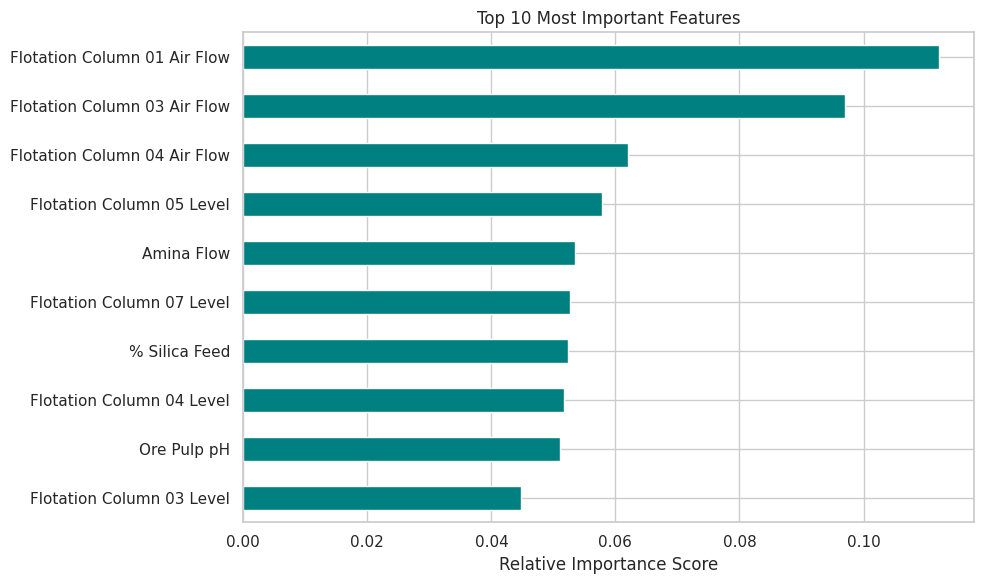

In [ ]:
# Cell 7: Model Train aur Test karna
import xgboost as xgb
from sklearn.metrics import mean_squared_error, r2_score
import matplotlib.pyplot as plt

print("XGBoost Model train ho raha hai (is mein kuch seconds lag sakte hain)...")

# Model initialize aur fit karna
model = xgb.XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)
model.fit(X_train, y_train)

# Predictions
y_pred = model.predict(X_test)

# Metrics calculate karna
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("="*40)
print(f"MODEL EVALUATION ({hours_ahead} Hour Ahead)")
print(f"Root Mean Squared Error (RMSE): {rmse:.4f}")
print(f"R-squared Score ($R^2$): {r2:.4f}")
print("="*40)

# Feature Importance Plot
feature_importances = pd.Series(model.feature_importances_, index=X_train.columns)
plt.figure(figsize=(10, 6))
feature_importances.nlargest(10).sort_values().plot(kind='barh', color='teal')
plt.title('Top 10 Most Important Features')
plt.xlabel('Relative Importance Score')
plt.tight_layout()
plt.show()

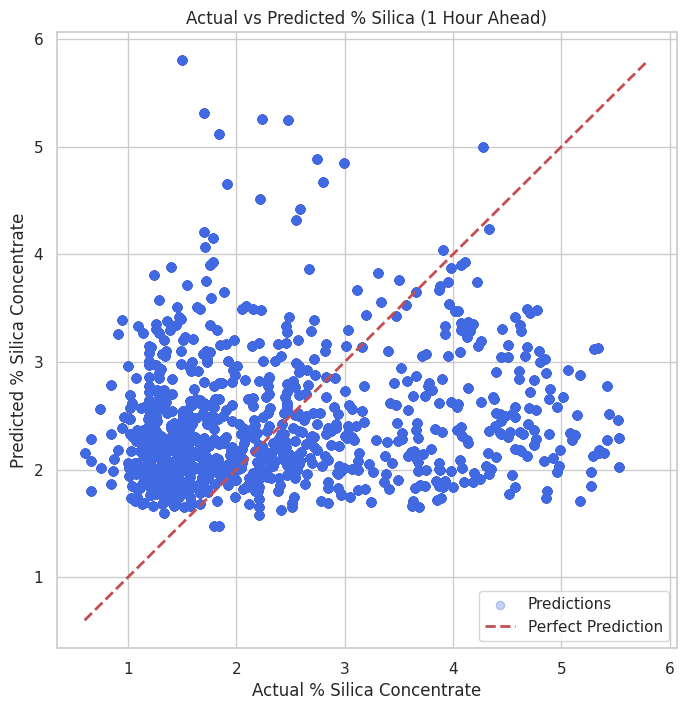

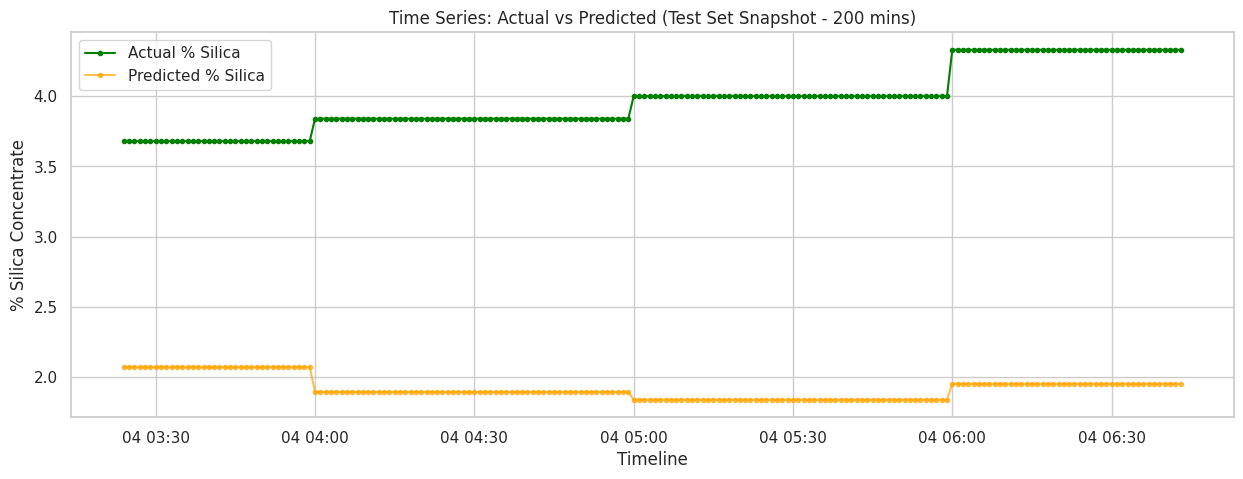

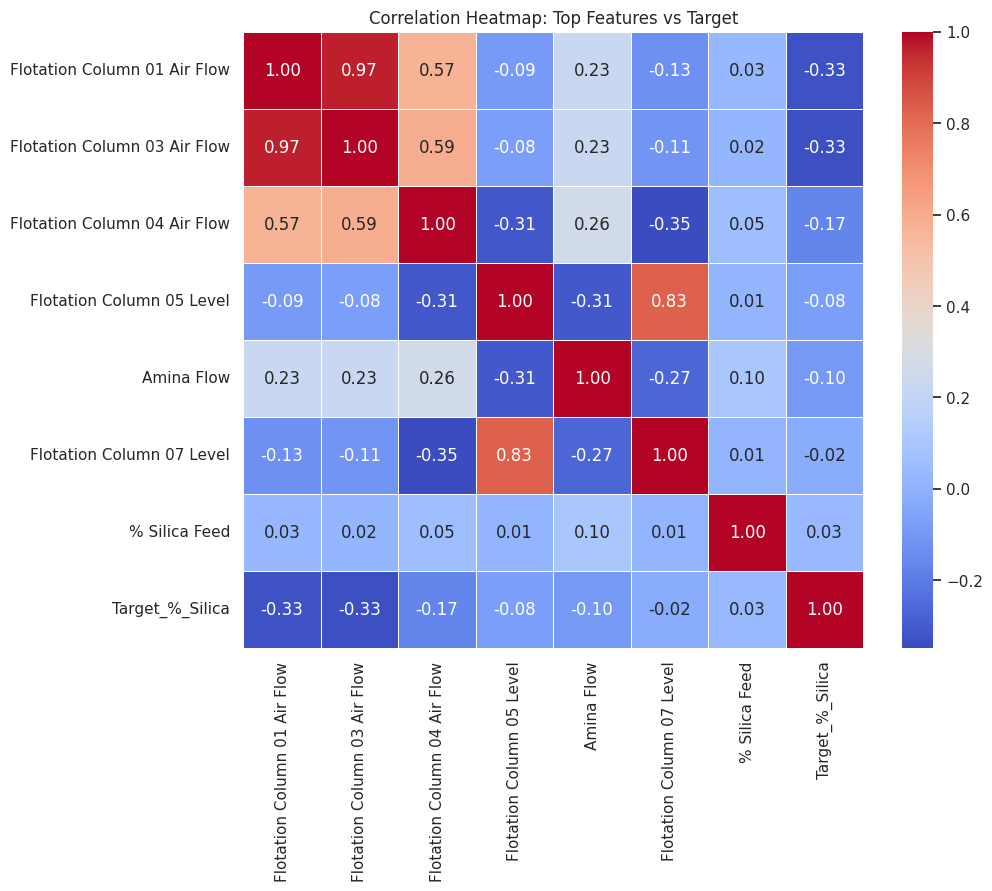

In [ ]:
# Cell 8: Advanced Visualizations for Model Evaluation
import seaborn as sns
import matplotlib.pyplot as plt

# Graph styles ko thoda professional banate hain
sns.set_theme(style="whitegrid")

# ==========================================
# 1. Actual vs Predicted Scatter Plot
# ==========================================
plt.figure(figsize=(8, 8))
plt.scatter(y_test, y_pred, alpha=0.3, color='royalblue', label='Predictions')

# Ek perfect prediction line (y=x) draw karte hain
min_val = min(y_test.min(), y_pred.min())
max_val = max(y_test.max(), y_pred.max())
plt.plot([min_val, max_val], [min_val, max_val], 'r--', lw=2, label='Perfect Prediction')

plt.xlabel('Actual % Silica Concentrate')
plt.ylabel('Predicted % Silica Concentrate')
plt.title(f'Actual vs Predicted % Silica ({hours_ahead} Hour Ahead)')
plt.legend()
plt.show()

# ==========================================
# 2. Time-Series Tracking (First 200 Minutes)
# ==========================================
# Pura test data plot karenge toh line bohot messy ho jayegi,
# isliye hum sirf shuruwati 200 minutes ka trend dekh rahe hain
window_size = 200

plt.figure(figsize=(15, 5))
plt.plot(y_test.index[:window_size], y_test.values[:window_size], label='Actual % Silica', color='green', marker='.')
plt.plot(y_test.index[:window_size], y_pred[:window_size], label='Predicted % Silica', color='orange', marker='.', alpha=0.7)

plt.xlabel('Timeline')
plt.ylabel('% Silica Concentrate')
plt.title(f'Time Series: Actual vs Predicted (Test Set Snapshot - {window_size} mins)')
plt.legend()
plt.show()

# ==========================================
# 3. Correlation Heatmap of Top Features & Target
# ==========================================
# Top 7 important features nikalte hain taaki heatmap clean rahe
top_7_features = feature_importances.nlargest(7).index.tolist()

# In top features aur target ko mila kar ek naya dataframe banate hain sirf correlation ke liye
corr_data = X_train[top_7_features].copy()
corr_data['Target_%_Silica'] = y_train

plt.figure(figsize=(10, 8))
# Heatmap plot karna
sns.heatmap(corr_data.corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5)
plt.title('Correlation Heatmap: Top Features vs Target')
plt.show()